<a href="https://colab.research.google.com/github/renzoardiles-pixel/Colab-UNI/blob/main/SQL/SESI%C3%93N_5_TRIGGERS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

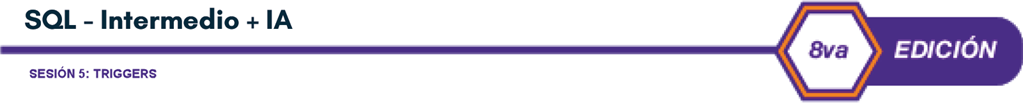

<table border=1 width='99%'>
<tr>
<td bgcolor='#4a235a'>

# **<font color="#FFFFFF">¿Que son los triggers o desencadenantes?</font>**

</td>
</tr>
</table>

Los triggers en SQL Server son un tipo de procedimiento almacenado que se ejecuta automáticamente en respuesta a ciertos eventos en la base de datos.

Los triggers pueden ser muy útiles para mantener la integridad de los datos y realizar auditorías.

<table width='99%'>
<tr>
<td bgcolor='#FF6600'>

## **<font color="#FFFFFF">Tipos de Triggers</font>**

</td>
</tr>
</table>

>* **DML Triggers (Data Manipulation Language)**:
    * Se ejecutan en respuesta a eventos de modificación de datos como INSERT, UPDATE y DELETE.
    * Se pueden definir como:
        * **AFTER Triggers**: Se ejecutan después de que la instrucción DML se ha completado.
        * **INSTEAD OF Triggers**: Se ejecutan en lugar de la instrucción DML.

>* **DDL Triggers (Data Definition Language)**:
    * Se ejecutan en respuesta a cambios en el esquema de la base de datos, como CREATE, ALTER y DROP.

>* **LOGON Triggers**:
    * Se ejecutan en respuesta a eventos de inicio de sesión en la base de datos.

<table width='99%'>
<tr>
<td bgcolor='#FF6600'>

## **<font color="#FFFFFF">Uso de Triggers</font>**

</td>
</tr>
</table>

>* Implementar lógica empresarial que valga antes o después de una operación DML.
>* Validar datos antes de ser insertados o actualizados.
>* Registrar cambios en otras tablas (auditoría).
>* Evitar operaciones que no deberían ocurrir.

<table width='99%'>
<tr>
<td bgcolor='#FF6600'>

## **<font color="#FFFFFF">Forma de Calcular el Stock en NorthwindSQL</font>**

</td>
</tr>
</table>



```
USE NorthwindSQL;
GO
SELECT p.Id AS IdProducto
	,p.[Nombre del producto]
	,
	SUM
	(
		CONVERT
		(
			INT,
			CONCAT
			(
				CASE t.[Tipo de transacción]
					WHEN 1 THEN '+'
					WHEN 2 THEN '-'
					WHEN 3 THEN '-'
					WHEN 4 THEN '+'
				END
				,t.Cantidad
			)
		)
	) AS Cantidad
FROM Almacen.Productos p
INNER JOIN Almacen.[Transacciones de inventario] t ON p.Id = t.[Id de producto]
GROUP BY p.Id, p.[Nombre del producto]
ORDER BY 3 DESC;
GO
```





```
USE NorthwindSQL;
GO
SELECT
	SUM
	(
		CONVERT
		(
			INT,
			CONCAT
			(
				CASE t.[Tipo de transacción]
					WHEN 1 THEN '+'
					WHEN 2 THEN '-'
					WHEN 3 THEN '-'
					WHEN 4 THEN '+'
				END
				,t.Cantidad
			)
		)
	) AS Cantidad
FROM Almacen.Productos p
INNER JOIN Almacen.[Transacciones de inventario] t ON p.Id = t.[Id de producto]
WHERE p.Id = 57
GROUP BY p.Id, p.[Nombre del producto];
GO
```





```
USE [NorthwindSQL]
GO

SET ANSI_NULLS ON
GO

SET QUOTED_IDENTIFIER ON
GO

CREATE TABLE [dbo].[tbl_error_utr](
	[ErrorNumber] [int] NULL,
	[ErrorSeverity] [int] NULL,
	[ErrorState] [int] NULL,
	[ErrorProcedure] [nvarchar](128) NULL,
	[ErrorLine] [int] NULL,
	[ErrorMessage] [nvarchar](4000) NULL,
	[ErrorDateTime] [datetime] NOT NULL
) ON [PRIMARY]
GO
```





```
USE NorthwindSQL;
GO
ALTER TABLE Ventas.[Detalles de pedido]
ADD CONSTRAINT ak_ventas_detalles_de_pedido_id_de_producto_id_de_pedido
UNIQUE ([Id de producto], [Id de pedido]);
```



<table width='99%'>
<tr>
<td bgcolor='#FF6600'>

## **<font color="#FFFFFF">Triggers por inserción</font>**

</td>
</tr>
</table>

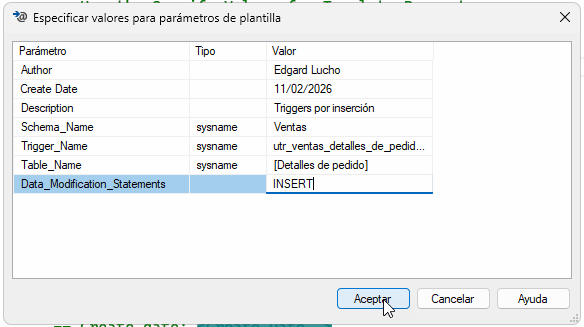



```
-- ================================================
-- Template generated from Template Explorer using:
-- Create Trigger (New Menu).SQL
--
-- Use the Specify Values for Template Parameters
-- command (Ctrl-Shift-M) to fill in the parameter
-- values below.
--
-- See additional Create Trigger templates for more
-- examples of different Trigger statements.
--
-- This block of comments will not be included in
-- the definition of the function.
-- ================================================
SET ANSI_NULLS ON
GO
SET QUOTED_IDENTIFIER ON
GO
-- =============================================
-- Author:		Edgard Lucho
-- Create date: 11/02/2026
-- Description:	Triggers por inserción
-- =============================================
CREATE OR ALTER TRIGGER Ventas.utr_ventas_detalles_de_pedido_insert
   ON  Ventas.[Detalles de pedido]
   AFTER INSERT
AS
BEGIN
	-- SET NOCOUNT ON added to prevent extra result sets from
	-- interfering with SELECT statements.
	SET NOCOUNT ON;
	DECLARE @Id							int;
	DECLARE @Id_de_pedido				int;
	DECLARE @Id_de_producto				int;
	DECLARE @Cantidad					decimal(18,4);
	DECLARE @Precio						money;
	DECLARE @Descuento					float;
	DECLARE @Id_de_situacion			int;
	DECLARE @Fecha_de_asignacion		datetime;
	DECLARE @Id_de_pedido_de_compra		int;
	DECLARE @Id_de_inventario			int;

	DECLARE @Stock						decimal(18,4);

	DECLARE @Costo_estandar				money
	DECLARE @Precio_listado				money;
	DECLARE @Suspendido					bit;

	DECLARE @Error						INT;
	DECLARE @ErrorCnt					INT;

	DECLARE @ErrorNumber		int;
	DECLARE @ErrorSeverity		int;
	DECLARE @ErrorState			int;
	DECLARE @ErrorProcedure		nvarchar(128);
	DECLARE @ErrorLine			int;
	DECLARE @ErrorMessage		nvarchar(4000);

	SELECT
		@Id = [Id]
		,@Id_de_pedido = [Id de pedido]
		,@Id_de_producto = [Id de producto]
		,@Cantidad = [Cantidad]
		,@Precio = [Precio]
		,@Descuento = [Descuento]
		,@Id_de_situacion = [Id de situación]
		,@Fecha_de_asignacion = [Fecha de asignación]
		,@Id_de_pedido_de_compra = [Id de pedido de compra]
		,@Id_de_inventario = [Id de inventario]
	FROM inserted;

	SET @Stock =
	(
		SELECT
			SUM
			(
				CONVERT
				(
					INT,
					CONCAT
					(
						CASE t.[Tipo de transacción]
							WHEN 1 THEN '+'
							WHEN 2 THEN '-'
							WHEN 3 THEN '-'
							WHEN 4 THEN '+'
						END
						,t.Cantidad
					)
				)
			) AS Cantidad
		FROM Almacen.Productos p
		INNER JOIN Almacen.[Transacciones de inventario] t ON p.Id = t.[Id de producto]
		WHERE p.Id = @Id_de_producto
		GROUP BY p.Id, p.[Nombre del producto]
	);
	SELECT
		 @Costo_estandar = [Costo estándar]
		,@Precio_listado = [Precio listado]
		,@Suspendido = [Suspendido]
	FROM [Almacen].[Productos]
	WHERE Id = @Id_de_producto

	BEGIN TRY
		IF @Suspendido = 1
		BEGIN
			SET @ErrorMessage = CONCAT('El producto con Id ', @Id_de_producto, ' está suspendido y no se puede vender.');
			THROW 50001, @ErrorMessage, 1;
		END
		IF
			NOT
			(
					@Precio * (1 - @Descuento) >= @Costo_estandar * 1.1
				AND
					@Precio * (1 - @Descuento) <= @Precio_listado
			)
		BEGIN
			SET @ErrorMessage = CONCAT
								(
									'El precio con descuento de ',
									@Precio * (1 - @Descuento),
									' para el producto con Id ',
									@Id_de_producto,
									' está por debajo del costo ',
									@Costo_estandar * 1.1
									,' y no se puede vender.');
			THROW 50002, @ErrorMessage, 1;
		END
		IF @Stock < @Cantidad
		BEGIN
			SET @ErrorMessage = CONCAT
								(
									'No hay suficiente stock para el producto con Id ',
									@Id_de_producto,
									'. Stock disponible: ',
									@Stock,
									', Cantidad solicitada: ',
									@Cantidad,
									'.');
			THROW 50003, @ErrorMessage, 1;
		END
		INSERT INTO [Almacen].[Transacciones de inventario]
		(
			[Tipo de transacción]
			,[Fecha de creación de la transacción]
			,[Fecha modificada de la transacción]
			,[Id de producto]
			,[Cantidad]
			,[Id de pedido de compra]
			,[Id de pedido de cliente]
			,[Comentarios]
		)
		VALUES
		(
			2
			,GetDate()
			,GetDate()
			,@Id_de_producto
			,@Cantidad
			,NULL
			,@Id_de_pedido
			,NULL
		);
		SELECT
			@Error = @@ERROR,
			@ErrorCnt = @@ROWCOUNT;

		IF @Error <> 0
		BEGIN
			SET @ErrorMessage = CONCAT('Error al insertar la transacción de inventario para el producto con Id ', @Id_de_producto, '.');
			THROW 50004, @ErrorMessage, 1;
		END
		IF @ErrorCnt = 0
		BEGIN
			SET @ErrorMessage = CONCAT('No se insertó ninguna transacción de inventario para el producto con Id ', @Id_de_producto, '.');
			THROW 50005, @ErrorMessage, 1;
		END

		SET @Id_de_inventario = SCOPE_IDENTITY();
		UPDATE Ventas.[Detalles de pedido]
		SET [Id de inventario] = @Id_de_inventario
		WHERE Id = @Id;
		SELECT
			@Error = @@ERROR,
			@ErrorCnt = @@ROWCOUNT;
		IF @Error <> 0
		BEGIN
			SET @ErrorMessage = CONCAT('Error al actualizar el Id de inventario para el detalle de pedido con Id ', @Id, '.');
			THROW 50006, @ErrorMessage, 1;
		END
		IF @ErrorCnt = 0
		BEGIN
			SET @ErrorMessage = CONCAT('No se actualizó el Id de inventario para el detalle de pedido con Id ', @Id, '.');
			THROW 50007, @ErrorMessage, 1;
		END

	END TRY
	BEGIN CATCH
		SELECT
			@ErrorNumber = ERROR_NUMBER(),
			@ErrorSeverity = ERROR_SEVERITY(),
			@ErrorState = ERROR_STATE(),
			@ErrorProcedure = ERROR_PROCEDURE(),
			@ErrorLine = ERROR_LINE(),
			@ErrorMessage = ERROR_MESSAGE();
		ROLLBACK TRANSACTION;

		-- Registrar el error en la tabla de errores
		INSERT INTO [dbo].[tbl_error_utr]
		(
			ErrorNumber,
			ErrorSeverity,
			ErrorState,
			ErrorProcedure,
			ErrorLine,
			ErrorMessage,
			ErrorDateTime
		)
		VALUES
		(
			@ErrorNumber,
			@ErrorSeverity,
			@ErrorState,
			@ErrorProcedure,
			@ErrorLine,
			@ErrorMessage,
			GETDATE()
		);
		THROW;
	END CATCH
END
GO

```





```
USE [NorthwindSQL]
GO

INSERT INTO [Ventas].[Detalles de pedido]
           ([Id de pedido]
           ,[Id de producto]
           ,[Cantidad]
           ,[Precio]
           ,[Descuento]
           ,[Id de situación]
           ,[Fecha de asignación]
           ,[Id de pedido de compra]
           ,[Id de inventario])
     VALUES
           (30
           ,5 ---Producto
           ,5 ---Cantidad
           ,18 -- Precio
           ,0   -- Descuento
           ,2 -- Id de situación
           ,GetDate()
           ,NULL
           ,NULL)
GO

```



<table width='99%'>
<tr>
<td bgcolor='#FF6600'>

## **<font color="#FFFFFF">Triggers por modificación</font>**

</td>
</tr>
</table>



```
-- ================================================
-- Template generated from Template Explorer using:
-- Create Trigger (New Menu).SQL
--
-- Use the Specify Values for Template Parameters
-- command (Ctrl-Shift-M) to fill in the parameter
-- values below.
--
-- See additional Create Trigger templates for more
-- examples of different Trigger statements.
--
-- This block of comments will not be included in
-- the definition of the function.
-- ================================================
SET ANSI_NULLS ON
GO
SET QUOTED_IDENTIFIER ON
GO
-- =============================================
-- Author:		Edgard Lucho
-- Create date: 11/02/2026
-- Description:	Triggers por modificación
-- =============================================
CREATE OR ALTER TRIGGER Ventas.utr_ventas_detalles_de_pedido_update
   ON  Ventas.[Detalles de pedido]
   AFTER UPDATE
AS
BEGIN
	-- SET NOCOUNT ON added to prevent extra result sets from
	-- interfering with SELECT statements.
	SET NOCOUNT ON;

	DECLARE @Id_deleted							int;
	DECLARE @Id_de_pedido_deleted				int;
	DECLARE @Id_de_producto_deleted				int;
	DECLARE @Cantidad_deleted					decimal(18,4);
	DECLARE @Precio_deleted						money;
	DECLARE @Descuento_deleted					float;
	DECLARE @Id_de_situacion_deleted			int;
	DECLARE @Fecha_de_asignacion_deleted		datetime;
	DECLARE @Id_de_pedido_de_compra_deleted		int;
	DECLARE @Id_de_inventario_deleted			int;

	DECLARE @Id_inserted							int;
	DECLARE @Id_de_pedido_inserted				int;
	DECLARE @Id_de_producto_inserted				int;
	DECLARE @Cantidad_inserted					decimal(18,4);
	DECLARE @Precio_inserted						money;
	DECLARE @Descuento_inserted					float;
	DECLARE @Id_de_situacion_inserted			int;
	DECLARE @Fecha_de_asignacion_inserted		datetime;
	DECLARE @Id_de_pedido_de_compra_inserted		int;
	DECLARE @Id_de_inventario_inserted			int;

	DECLARE @Stock						decimal(18,4);

	DECLARE @Costo_estandar				money
	DECLARE @Precio_listado				money;
	DECLARE @Suspendido					bit;

	DECLARE @Error						INT;
	DECLARE @ErrorCnt					INT;

	DECLARE @ErrorNumber		int;
	DECLARE @ErrorSeverity		int;
	DECLARE @ErrorState			int;
	DECLARE @ErrorProcedure		nvarchar(128);
	DECLARE @ErrorLine			int;
	DECLARE @ErrorMessage		nvarchar(4000);

	SELECT
		@Id_deleted = [Id]
		,@Id_de_pedido_deleted = [Id de pedido]
		,@Id_de_producto_deleted = [Id de producto]
		,@Cantidad_deleted = [Cantidad]
		,@Precio_deleted = [Precio]
		,@Descuento_deleted = [Descuento]
		,@Id_de_situacion_deleted = [Id de situación]
		,@Fecha_de_asignacion_deleted = [Fecha de asignación]
		,@Id_de_pedido_de_compra_deleted = [Id de pedido de compra]
		,@Id_de_inventario_deleted = [Id de inventario]
	FROM deleted;

	SELECT
		@Id_inserted = [Id]
		,@Id_de_pedido_inserted = [Id de pedido]
		,@Id_de_producto_inserted = [Id de producto]
		,@Cantidad_inserted = [Cantidad]
		,@Precio_inserted = [Precio]
		,@Descuento_inserted = [Descuento]
		,@Id_de_situacion_inserted = [Id de situación]
		,@Fecha_de_asignacion_inserted = [Fecha de asignación]
		,@Id_de_pedido_de_compra_inserted = [Id de pedido de compra]
		,@Id_de_inventario_inserted = [Id de inventario]
	FROM inserted;

	SET @Stock =
	(
		SELECT
			SUM
			(
				CONVERT
				(
					INT,
					CONCAT
					(
						CASE t.[Tipo de transacción]
							WHEN 1 THEN '+'
							WHEN 2 THEN '-'
							WHEN 3 THEN '-'
							WHEN 4 THEN '+'
						END
						,t.Cantidad
					)
				)
			) AS Cantidad
		FROM Almacen.Productos p
		INNER JOIN Almacen.[Transacciones de inventario] t ON p.Id = t.[Id de producto]
		WHERE p.Id = @Id_de_producto_inserted
		GROUP BY p.Id, p.[Nombre del producto]
	);
	SELECT
		 @Costo_estandar = [Costo estándar]
		,@Precio_listado = [Precio listado]
		,@Suspendido = [Suspendido]
	FROM [Almacen].[Productos]
	WHERE Id = @Id_de_producto_inserted;

	BEGIN TRY
		IF @Suspendido = 1
		BEGIN
			SET @ErrorMessage = CONCAT('El producto con Id ', @Id_de_producto_inserted, ' está suspendido y no se puede vender.');
			THROW 50001, @ErrorMessage, 1;
		END
		IF
			NOT
			(
					@Precio_inserted * (1 - @Descuento_inserted) >= @Costo_estandar * 1.1
				AND
					@Precio_inserted * (1 - @Descuento_inserted) <= @Precio_listado
			)
		BEGIN
			SET @ErrorMessage = CONCAT
								(
									'El precio con descuento de ',
									@Precio_inserted * (1 - @Descuento_inserted),
									' para el producto con Id ',
									@Id_de_producto_inserted,
									' está por debajo del costo ',
									@Costo_estandar * 1.1
									,' y no se puede vender.');
			THROW 50002, @ErrorMessage, 1;
		END
		IF @Stock + @Cantidad_deleted < @Cantidad_inserted
		BEGIN
			SET @ErrorMessage = CONCAT
								(
									'No hay suficiente stock para el producto con Id ',
									@Id_de_producto_inserted,
									'. Stock disponible: ',
									@Stock + @Cantidad_deleted,
									', Cantidad solicitada: ',
									@Cantidad_inserted,
									'.');
			THROW 50003, @ErrorMessage, 1;
		END

		UPDATE [Almacen].[Transacciones de inventario]
		SET
			[Fecha modificada de la transacción] = GetDate()
			,[Cantidad] = @Cantidad_inserted
			,[Comentarios] = 'Modificación'
		WHERE
				[Id de producto] = @Id_de_producto_inserted
			AND
				[Id de transacción] = @Id_de_inventario_deleted
			AND
				[Tipo de transacción] = 2 -- Venta
			AND
				[Id de pedido de cliente] = @Id_de_pedido_inserted;
		SELECT
			@Error = @@ERROR,
			@ErrorCnt = @@ROWCOUNT;

		IF @Error <> 0
		BEGIN
			SET @ErrorMessage = CONCAT('Error al modificar la transacción de inventario para el producto con Id ', @Id_de_producto_inserted, '.');
			THROW 50004, @ErrorMessage, 1;
		END
		IF @ErrorCnt = 0
		BEGIN
			SET @ErrorMessage = CONCAT('No se modifico ninguna transacción de inventario para el producto con Id ', @Id_de_producto_inserted, '.');
			THROW 50005, @ErrorMessage, 1;
		END

	END TRY
	BEGIN CATCH
		SELECT
			@ErrorNumber = ERROR_NUMBER(),
			@ErrorSeverity = ERROR_SEVERITY(),
			@ErrorState = ERROR_STATE(),
			@ErrorProcedure = ERROR_PROCEDURE(),
			@ErrorLine = ERROR_LINE(),
			@ErrorMessage = ERROR_MESSAGE();
		ROLLBACK TRANSACTION;

		-- Registrar el error en la tabla de errores
		INSERT INTO [dbo].[tbl_error_utr]
		(
			ErrorNumber,
			ErrorSeverity,
			ErrorState,
			ErrorProcedure,
			ErrorLine,
			ErrorMessage,
			ErrorDateTime
		)
		VALUES
		(
			@ErrorNumber,
			@ErrorSeverity,
			@ErrorState,
			@ErrorProcedure,
			@ErrorLine,
			@ErrorMessage,
			GETDATE()
		);
		THROW;
	END CATCH
END
GO
```



<table width='99%'>
<tr>
<td bgcolor='#FF6600'>

## **<font color="#FFFFFF">Triggers por eliminación</font>**

</td>
</tr>
</table>



```
-- ================================================
-- Template generated from Template Explorer using:
-- Create Trigger (New Menu).SQL
--
-- Use the Specify Values for Template Parameters
-- command (Ctrl-Shift-M) to fill in the parameter
-- values below.
--
-- See additional Create Trigger templates for more
-- examples of different Trigger statements.
--
-- This block of comments will not be included in
-- the definition of the function.
-- ================================================
SET ANSI_NULLS ON
GO
SET QUOTED_IDENTIFIER ON
GO
-- =============================================
-- Author:		Edgard Lucho
-- Create date: 11/02/2026
-- Description:	Triggers por eliminación
-- =============================================
CREATE OR ALTER TRIGGER Ventas.utr_ventas_detalles_de_pedido_delete
   ON  Ventas.[Detalles de pedido]
   AFTER DELETE
AS
BEGIN
	-- SET NOCOUNT ON added to prevent extra result sets from
	-- interfering with SELECT statements.
	SET NOCOUNT ON;

	DECLARE @Id_deleted							int;
	DECLARE @Id_de_pedido_deleted				int;
	DECLARE @Id_de_producto_deleted				int;
	DECLARE @Cantidad_deleted					decimal(18,4);
	DECLARE @Precio_deleted						money;
	DECLARE @Descuento_deleted					float;
	DECLARE @Id_de_situacion_deleted			int;
	DECLARE @Fecha_de_asignacion_deleted		datetime;
	DECLARE @Id_de_pedido_de_compra_deleted		int;
	DECLARE @Id_de_inventario_deleted			int;

	DECLARE @Error						INT;
	DECLARE @ErrorCnt					INT;

	DECLARE @ErrorNumber		int;
	DECLARE @ErrorSeverity		int;
	DECLARE @ErrorState			int;
	DECLARE @ErrorProcedure		nvarchar(128);
	DECLARE @ErrorLine			int;
	DECLARE @ErrorMessage		nvarchar(4000);

	SELECT
		@Id_deleted = [Id]
		,@Id_de_pedido_deleted = [Id de pedido]
		,@Id_de_producto_deleted = [Id de producto]
		,@Cantidad_deleted = [Cantidad]
		,@Precio_deleted = [Precio]
		,@Descuento_deleted = [Descuento]
		,@Id_de_situacion_deleted = [Id de situación]
		,@Fecha_de_asignacion_deleted = [Fecha de asignación]
		,@Id_de_pedido_de_compra_deleted = [Id de pedido de compra]
		,@Id_de_inventario_deleted = [Id de inventario]
	FROM deleted;

	BEGIN TRY
		DELETE [Almacen].[Transacciones de inventario]
		WHERE
				[Id de producto] = @Id_de_producto_deleted
			AND
				[Id de transacción] = @Id_de_inventario_deleted
			AND
				[Tipo de transacción] = 2 -- Venta
			AND
				[Id de pedido de cliente] = @Id_de_pedido_deleted;
		SELECT
			@Error = @@ERROR,
			@ErrorCnt = @@ROWCOUNT;

		IF @Error <> 0
		BEGIN
			SET @ErrorMessage = CONCAT('Error al eliminar la transacción de inventario para el producto con Id ', @Id_de_producto_deleted, '.');
			THROW 50004, @ErrorMessage, 1;
		END
		IF @ErrorCnt = 0
		BEGIN
			SET @ErrorMessage = CONCAT('No se elimino ninguna transacción de inventario para el producto con Id ', @Id_de_producto_deleted, '.');
			THROW 50005, @ErrorMessage, 1;
		END

	END TRY
	BEGIN CATCH
		SELECT
			@ErrorNumber = ERROR_NUMBER(),
			@ErrorSeverity = ERROR_SEVERITY(),
			@ErrorState = ERROR_STATE(),
			@ErrorProcedure = ERROR_PROCEDURE(),
			@ErrorLine = ERROR_LINE(),
			@ErrorMessage = ERROR_MESSAGE();
		ROLLBACK TRANSACTION;

		-- Registrar el error en la tabla de errores
		INSERT INTO [dbo].[tbl_error_utr]
		(
			ErrorNumber,
			ErrorSeverity,
			ErrorState,
			ErrorProcedure,
			ErrorLine,
			ErrorMessage,
			ErrorDateTime
		)
		VALUES
		(
			@ErrorNumber,
			@ErrorSeverity,
			@ErrorState,
			@ErrorProcedure,
			@ErrorLine,
			@ErrorMessage,
			GETDATE()
		);
		THROW;
	END CATCH
END
GO
```

